# Seq++ with PTO: Evolutionary Irish Music Generation

1. **Setup** — Install PTO library, load calibration  
2. **Corpus Analysis** — Explore the Irish tune corpus calibration data  
3. **Generator** — The Seq++ music generator (adapted for PTO's `rnd`)  
4. **Fitness** — Complexity (NPC) + Rhythm scoring  
5. **Evolution** — Run PTO GA to evolve tunes  
6. **Analysis** — Inspect and export results

## 1. Setup

In [1]:
%pip install git+https://github.com/Program-Trace-Optimisation/PTO.git -q

^C
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/__main__.py", line 24, in <module>
    sys.exit(_main())
             ^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/cli/main.py", line 79, in main
    return command.main(cmd_args)
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 101, in main
    return self._main(args)
           ^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 236, in _main
    self.handle_pip_version_check(options)
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/cli/req_command.py", line 177, in handle_pip_version_check
    session = self._build_session(
              ^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages

In [ ]:
import pickle, math, os, re
from collections import Counter
from typing import Dict, List, Tuple, Optional, Any
import matplotlib.pyplot as plt
import numpy as np

from pto import run, rnd
print("PTO imported successfully")

# Output directory for plots
os.makedirs('plots', exist_ok=True)

# Supporting modules (keep as .py files alongside this notebook)
import decoder
from decoder import decode_to_melody, decode
from calculate_irish_npc_complete import encode_chunks_incremental, NPCCalculator, VAR_FUNCS

PTO imported successfully


In [ ]:
import pickle

with open('cre_calibration.pkl', 'rb') as f:
    calibration = pickle.load(f)

# Fix: sync total_corpus with actual npc_values count
calibration['total_corpus'] = len(calibration['npc_values'])

with open('cre_calibration.pkl', 'wb') as f:
    pickle.dump(calibration, f)

print(f"Fixed: total_corpus now = {calibration['total_corpus']}")

# with open('cre_calibration.pkl', 'rb') as f:
#     calibration = pickle.load(f)

print(f"Corpus size:  {calibration['total_corpus']} tunes")
print(f"NPC mean:     {calibration['npc_mean']:.2f}")
print(f"NPC std:      {calibration['npc_std']:.2f}")
print(f"NPC values:   {len(calibration.get('npc_values', []))} computed")
print(f"Time sigs:    {list(calibration['pattern_tables'].keys())}")
for ts, table in calibration['pattern_tables'].items():
    total = sum(table.values())
    print(f"  {ts}: {len(table)} unique patterns from {total} tunes")

Fixed: total_corpus now = 1195
Corpus size:  1195 tunes
NPC mean:     138.56
NPC std:      49.20
NPC values:   1195 computed
Time sigs:    ['4/4', '6/8', '9/8', '12/8', '2/4']
  4/4: 742 unique patterns from 743 tunes
  6/8: 248 unique patterns from 260 tunes
  9/8: 52 unique patterns from 52 tunes
  12/8: 76 unique patterns from 76 tunes
  2/4: 83 unique patterns from 83 tunes


## 2. Corpus Analysis

### 2.1 NPC Distribution

NPC (Nested Pattern Complexity) measures the cost of constructing a tune's hierarchical representation. 
The fitness function rewards generated tunes whose NPC is close to the corpus mean.

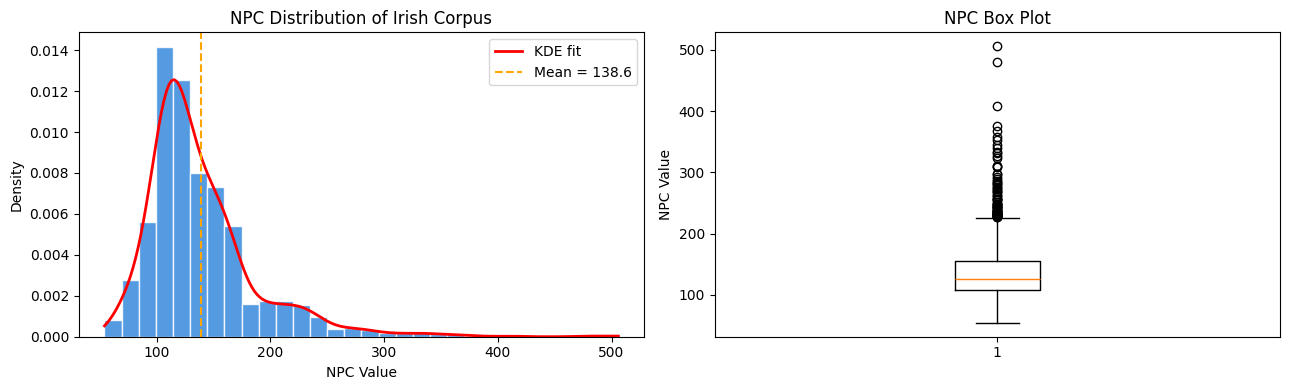

Min: 54.0, Q1: 108.0, Median: 126.0, Q3: 155.0, Max: 506.0


In [ ]:
npc_values = calibration.get('npc_values', [])

if npc_values:
    from scipy.stats import gaussian_kde
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(npc_values, bins=30, color='#378ADD', edgecolor='white', alpha=0.85, density=True)
    # Overlay KDE
    x_grid = np.linspace(min(npc_values), max(npc_values), 200)
    kde = gaussian_kde(npc_values)
    axes[0].plot(x_grid, kde(x_grid), 'r-', linewidth=2, label='KDE fit')
    axes[0].axvline(calibration['npc_mean'], color='orange', linestyle='--', linewidth=1.5, label=f"Mean = {calibration['npc_mean']:.1f}")
    axes[0].set_xlabel('NPC Value'); axes[0].set_ylabel('Density')
    axes[0].set_title('NPC Distribution of Irish Corpus'); axes[0].legend()
    axes[1].boxplot(npc_values, vert=True)
    axes[1].set_ylabel('NPC Value'); axes[1].set_title('NPC Box Plot')
    plt.tight_layout()
    plt.savefig('plots/npc_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Min: {min(npc_values):.1f}, Q1: {np.percentile(npc_values,25):.1f}, "
          f"Median: {np.median(npc_values):.1f}, Q3: {np.percentile(npc_values,75):.1f}, Max: {max(npc_values):.1f}")
else:
    print("No NPC values in calibration (rhythm-only calibration)")

### 2.2 Rhythm Profiles

Each tune's note onsets are collapsed into a single-bar histogram at 16th-note resolution.
The corpus provides a table of all unique histograms per time signature, each with a frequency count.

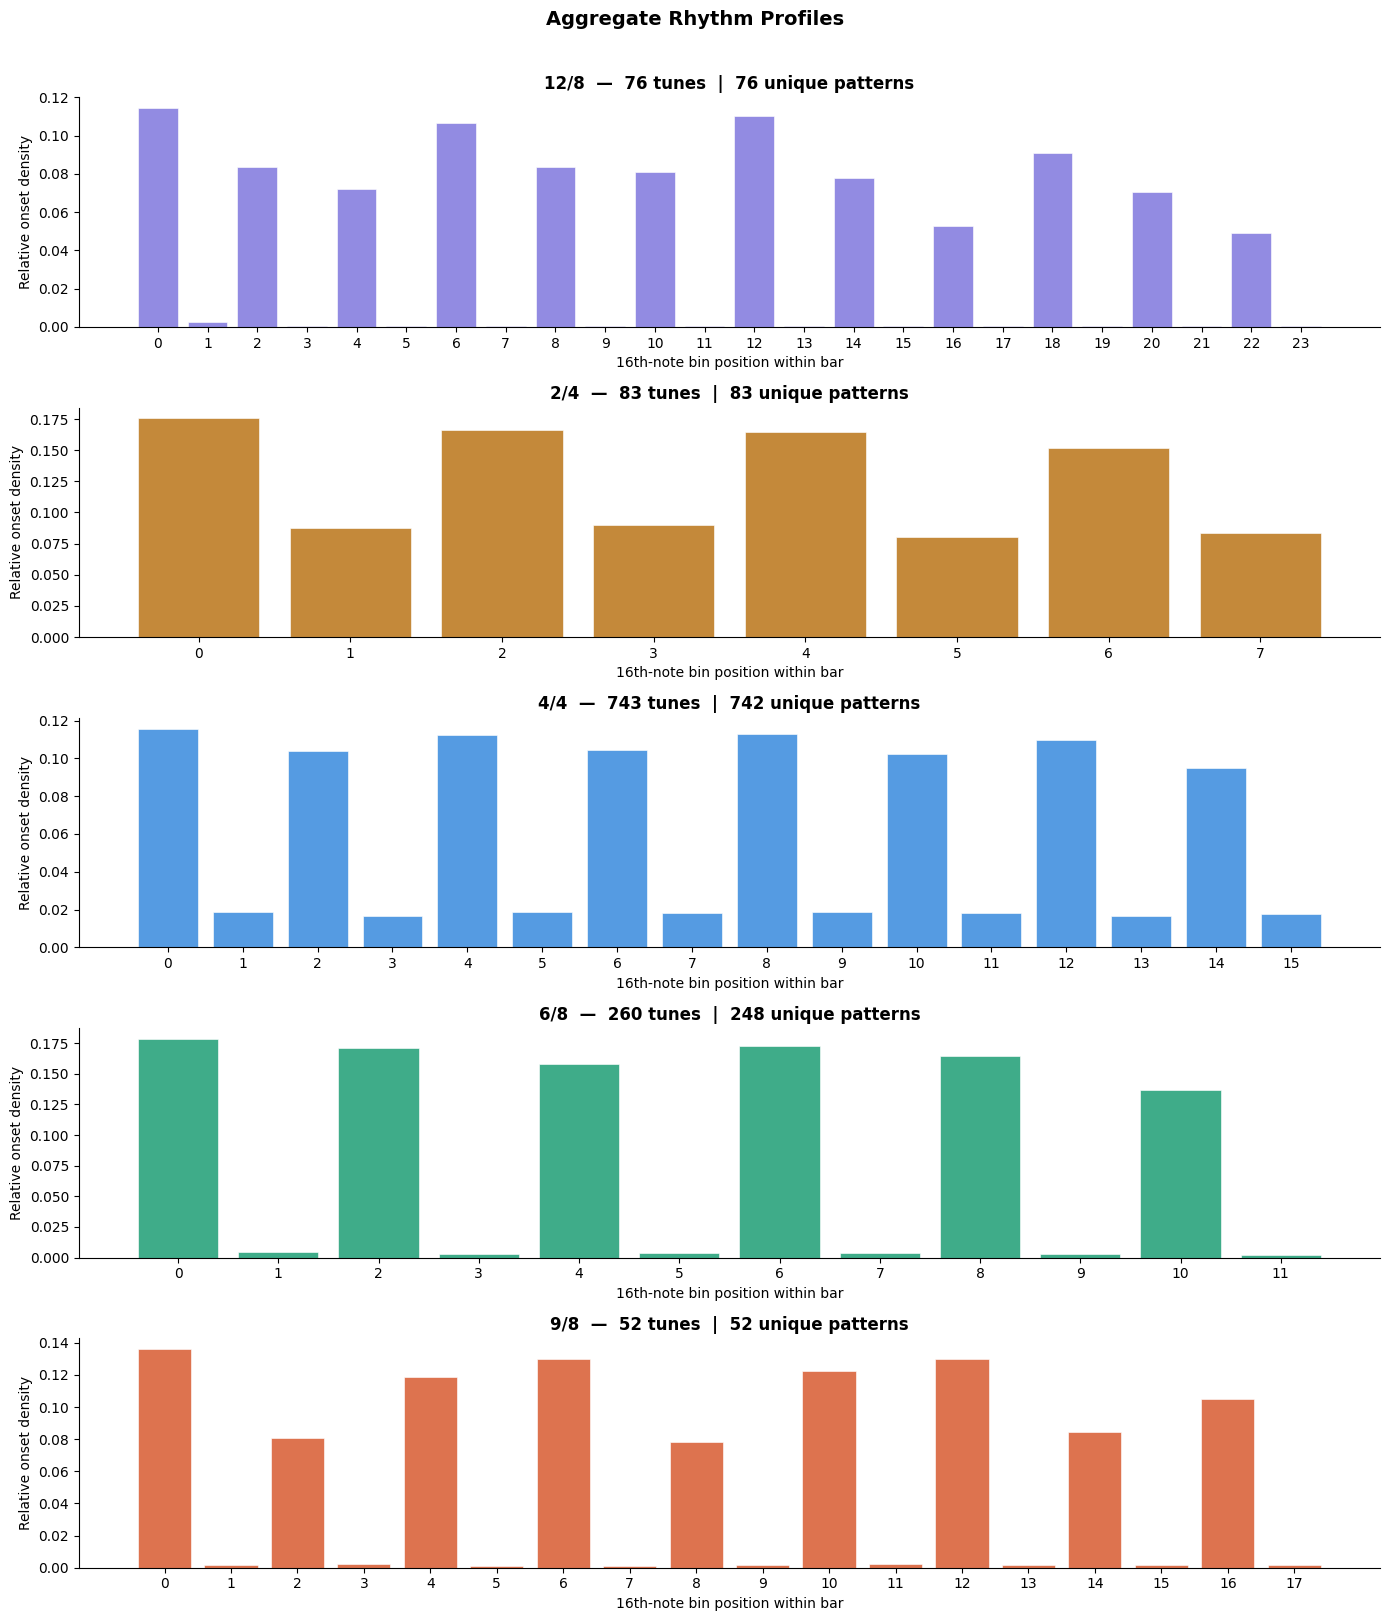

In [ ]:
TS_COLORS = {'6/8': '#1D9E75', '4/4': '#378ADD', '9/8': '#D85A30',
             '12/8': '#7F77DD', '2/4': '#BA7517', '3/4': '#D4537E'}
tables = calibration['pattern_tables']
ts_list = sorted(tables.keys())
n = len(ts_list)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.2 * n))
if n == 1: axes = [axes]
for idx, ts in enumerate(ts_list):
    table = tables[ts]
    n_bins = len(next(iter(table)))
    agg = [0.0] * n_bins
    total = sum(table.values())
    for hist, count in table.items():
        for i, v in enumerate(hist):
            agg[i] += v * count
    s = sum(agg)
    if s > 0: agg = [v / s for v in agg]
    ax = axes[idx]
    ax.bar(range(n_bins), agg, color=TS_COLORS.get(ts, '#888'), alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(f"{ts}  \u2014  {total} tunes  |  {len(table)} unique patterns", fontsize=12, fontweight='bold')
    ax.set_xlabel("16th-note bin position within bar"); ax.set_ylabel("Relative onset density")
    ax.set_xticks(range(n_bins)); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle("Aggregate Rhythm Profiles", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/rhythm_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Pattern Frequency Analysis

In [ ]:
for ts in sorted(tables.keys()):
    table = tables[ts]
    total = sum(table.values())
    sorted_patterns = sorted(table.values(), reverse=True)
    print(f"\n{'='*50}")
    print(f"{ts}: {len(table)} patterns from {total} tunes")
    print(f"{'='*50}")
    cumulative = 0
    for i, count in enumerate(sorted_patterns, 1):
        cumulative += count
        pct = cumulative / total * 100
        if pct >= 50 and i == next(j for j, c in enumerate(sorted_patterns, 1) if sum(sorted_patterns[:j]) / total * 100 >= 50):
            print(f"  Top {i} patterns cover 50% of tunes")
        if pct >= 80 and i == next(j for j, c in enumerate(sorted_patterns, 1) if sum(sorted_patterns[:j]) / total * 100 >= 80):
            print(f"  Top {i} patterns cover 80% of tunes")
        if pct >= 90 and i == next(j for j, c in enumerate(sorted_patterns, 1) if sum(sorted_patterns[:j]) / total * 100 >= 90):
            print(f"  Top {i} patterns cover 90% of tunes")
            break
    sorted_p = sorted(table.items(), key=lambda x: -x[1])[:5]
    print(f"  Top 5 patterns:")
    for rank, (pattern, count) in enumerate(sorted_p, 1):
        pct = count / total * 100
        active = [(i, round(v, 2)) for i, v in enumerate(pattern) if v > 0.005]
        print(f"    #{rank}: {count} tunes ({pct:.1f}%) \u2014 active bins: {active}")


12/8: 76 patterns from 76 tunes
  Top 38 patterns cover 50% of tunes
  Top 61 patterns cover 80% of tunes
  Top 69 patterns cover 90% of tunes
  Top 5 patterns:
    #1: 1 tunes (1.3%) — active bins: [(0, 0.13), (1, 0.01), (2, 0.13), (6, 0.1), (8, 0.13), (12, 0.1), (14, 0.13), (16, 0.03), (18, 0.1), (20, 0.13), (22, 0.02)]
    #2: 1 tunes (1.3%) — active bins: [(0, 0.12), (2, 0.03), (4, 0.1), (6, 0.12), (8, 0.03), (10, 0.12), (12, 0.12), (14, 0.04), (16, 0.12), (18, 0.12), (22, 0.07)]
    #3: 1 tunes (1.3%) — active bins: [(0, 0.1), (2, 0.12), (6, 0.12), (8, 0.12), (10, 0.09), (12, 0.12), (14, 0.12), (16, 0.03), (18, 0.06), (20, 0.12), (22, 0.01)]
    #4: 1 tunes (1.3%) — active bins: [(0, 0.11), (2, 0.08), (4, 0.11), (6, 0.1), (8, 0.04), (10, 0.1), (12, 0.1), (14, 0.1), (16, 0.1), (18, 0.1), (22, 0.08)]
    #5: 1 tunes (1.3%) — active bins: [(0, 0.11), (2, 0.13), (4, 0.05), (6, 0.13), (8, 0.13), (12, 0.13), (14, 0.13), (18, 0.06), (20, 0.13)]

2/4: 83 patterns from 83 tunes
  Top 42 p

## 3. Generator (Seq++ for PTO)

The generator creates a hierarchical music structure using `rnd` (PTO's traced random module).
Every `rnd.*` call is recorded by PTO as part of the program trace (genotype). 
The music structure returned is the phenotype.

In [ ]:
# =============================================================================
# Seq++ Generator — uses PTO's `rnd`
# =============================================================================

def generate(
    chunks_range=(4, 6), chunk_length_range=(1, 4),
    ho_patterns_range=(0, 1), au_patterns_range=(0, 3),
    grammar_range=(2, 3), element_length_range=(3, 5),
    transform_prob=0.40, ho_transform_prob=0.25,
    transposition_intervals=None, pitch_range=(0, 7),
):
    """Seq++ music generator. All random decisions use PTO's `rnd`."""

    def create_random_duration_partition(target_duration, feel):
        """Create a random partition of a target musical duration."""
        durations = []
        remaining = target_duration
        if feel == 'straight':
            all_types = [(2, 10), (1, 30), (0.5, 40), (0.25, 20)]
        else:
            all_types = [(1, 30), (2/3, 20), (1/3, 60), (1/6, 20)]
        # num_types = rnd.choice([2, 3])
        # note_types = rnd.sample(all_types, min(num_types, len(all_types)))

        use_mask = [rnd.random() < 0.7 for _ in all_types]
        note_types = [t for t, use in zip(all_types, use_mask) if use]
        if not note_types:
            note_types = [all_types[rnd.randint(0, len(all_types) - 1)]]
            
        max_notes = int(target_duration / min(d for d, _ in note_types)) + 2
        for _ in range(max_notes):
            if remaining <= 0.01:
                break
            choices, weights = [], []
            for note_len, weight in note_types:
                if note_len <= remaining + 0.01:
                    choices.append(note_len)
                    weights.append(weight)
            if not choices:
                break
            chosen = rnd.choices(choices, weights=weights)[0]
            durations.append(chosen)
            remaining -= chosen
        return durations
    if transposition_intervals is None:
        transposition_intervals = [-5, -3, -2, 2, 3, 5]

    num_chunks = rnd.randint(*chunks_range)
    num_ho_patterns = rnd.randint(*ho_patterns_range)
    num_au_patterns = rnd.randint(*au_patterns_range)
    time_sig = rnd.choice(['4/4', '3/4', '2/4', '6/8', '9/8', '12/8'])
    feel = 'triplet' if rnd.random() < 0.15 else 'straight'
    # feel = rnd.choices(['straight', 'triplet'], weights=[85, 15])[0]
    
    # 1. Chunks
    chunks = {}
    for i in range(num_chunks):
        chunk_length = rnd.randint(*chunk_length_range)
        note_durations = create_random_duration_partition(chunk_length, feel)
        notes = [(rnd.randint(*pitch_range), d) for d in note_durations]
        chunks[f"c_{i}"] = notes

    # 2. HO patterns
    ho_patterns = {}
    for i in range(num_ho_patterns):
        ho_len = rnd.randint(*element_length_range)
        ho_patterns[f"ho_{i}"] = [f"c_{rnd.randint(0, num_chunks - 1)}" for _ in range(ho_len)]

    # 3. AU patterns
    au_patterns = {}
    for i in range(num_au_patterns):
        num_variables = rnd.choice([1, 2])
        pattern_length = rnd.randint(*element_length_range)
        if num_variables == 1:
            variables = ["X1"]
            pattern_type = rnd.choice(["transpose_var", "mixed"])
            if pattern_type == "transpose_var":
                c1, c2 = rnd.randint(0, num_chunks-1), rnd.randint(0, num_chunks-1)
                pattern = [f"c_{c1}", f"T(c_{c2},X1)"]
            else:
                pattern = []
                for _ in range(pattern_length):
                    ci = rnd.randint(0, num_chunks - 1)
                    tt = rnd.choice(["plain", "transpose", "invert", "augment"])
                    if tt == "plain":      pattern.append(f"c_{ci}")
                    elif tt == "transpose": pattern.append(f"T(c_{ci},X1)")
                    elif tt == "invert":    pattern.append(f"I(c_{ci},X1)")
                    elif tt == "augment":   pattern.append(f"A(c_{ci},X1)")
        else:
            variables = ["X1", "X2"]
            ci = rnd.randint(0, num_chunks - 1)
            # pattern = rnd.choice([
            #     [f"c_{ci}", "X1", f"T(c_{ci},X2)", "T(X1,X2)"],
            #     [f"c_{ci}", "T(X1,X2)", f"G(c_{ci})"],
            #     ["X1", f"T(c_{ci},X2)", "X1"],
            #     ["X1", f"G(c_{ci})", "T(X1,X2)"],
            #     [f"c_{ci}", "X1", "T(X1,X2)"],
            # ])
            _templates = [
                [f"c_{ci}", "X1", f"T(c_{ci},X2)", "T(X1,X2)"],
                [f"c_{ci}", "T(X1,X2)", f"G(c_{ci})"],
                ["X1", f"T(c_{ci},X2)", "X1"],
                ["X1", f"G(c_{ci})", "T(X1,X2)"],
                [f"c_{ci}", "X1", "T(X1,X2)"],
            ]
            pattern = _templates[rnd.randint(0, 4)]
        au_patterns[f"f_{i}"] = {"pattern": pattern, "variables": variables}

    # 4. Grammar
    grammar = {}
    # forms = [["p_1","p_2","p_1"], ["p_1","p_2","p_1","p_2"], ["p_1","p_2","p_2","p_1"]]
    # grammar["p_0"] = rnd.choice(forms)

    form_idx = rnd.randint(0, 2)
    forms = [["p_1","p_2","p_1"], ["p_1","p_2","p_1","p_2"], ["p_1","p_2","p_2","p_1"]]
    grammar["p_0"] = forms[form_idx]

    rules_to_generate = set(grammar["p_0"])
    rules_generated = {"p_0"}
    next_rule_num = max(int(r.split("_")[1]) for r in grammar["p_0"]) + 1

    while rules_to_generate:
        rule_name = min(rules_to_generate)
        rules_to_generate.remove(rule_name)
        rules_generated.add(rule_name)
        rule_length = rnd.randint(*element_length_range)
        elements = []
        for _ in range(rule_length):
            available_types = ["chunk"]
            if num_ho_patterns > 0: available_types.append("ho_pattern")
            if num_au_patterns > 0: available_types.append("au_pattern")
            if rnd.random() < 0.4:  available_types.append("grammar_rule")
            element_type = rnd.choice(available_types)

            if element_type == "chunk":
                chunk_ref = f"c_{rnd.randint(0, num_chunks - 1)}"
                if rnd.random() < transform_prob:
                    trans = rnd.choices(["T", "G", "I", "P", "H"], weights=[80, 5, 5, 5, 5])[0]
                    if trans == "T":
                        elements.append(f"T({chunk_ref},{rnd.choice(transposition_intervals)})")
                    elif trans == "G":
                        elements.append(f"G({chunk_ref})")
                    elif trans == "I":
                        elements.append(f"I({chunk_ref},0)")
                    elif trans == "P":
                        pos = rnd.randint(0, len(chunks[chunk_ref]) - 1)
                        elements.append(f"P({chunk_ref},{pos},{rnd.randint(0, 7)})")
                    elif trans == "H":
                        pos = rnd.randint(0, len(chunks[chunk_ref]) - 1)
                        elements.append(f"H({chunk_ref},{pos},{rnd.choice([0.5, 1, 1.5])})")
                else:
                    elements.append(chunk_ref)
            elif element_type == "ho_pattern" and num_ho_patterns > 0:
                ho_ref = f"ho_{rnd.randint(0, num_ho_patterns - 1)}"
                if rnd.random() < ho_transform_prob:
                    trans = rnd.choices(["T", "G", "A", "D"], weights=[80, 7, 7, 6])[0]
                    if trans == "T":   elements.append(f"T({ho_ref},{rnd.choice(transposition_intervals)})")
                    elif trans == "G": elements.append(f"G({ho_ref})")
                    elif trans == "A": elements.append(f"A({ho_ref},{rnd.choice([2, 3])})")
                    elif trans == "D": elements.append(f"D({ho_ref},2)")
                else:
                    elements.append(ho_ref)
            elif element_type == "au_pattern" and num_au_patterns > 0:
                func_idx = rnd.randint(0, num_au_patterns - 1)
                num_vars = len(au_patterns[f"f_{func_idx}"]["variables"])
                if num_vars == 1:
                    elements.append(f"f_{func_idx}({rnd.choice(transposition_intervals)})")
                else:
                    elements.append(f"f_{func_idx}(c_{rnd.randint(0, num_chunks-1)},{rnd.choice(transposition_intervals)})")
            elif element_type == "grammar_rule":
                existing = [e for e in elements if e.startswith("p_")]
                if existing and rnd.random() < 0.7:
                    elements.append(rnd.choice(existing))
                else:
                    new_rule = f"p_{next_rule_num}"
                    next_rule_num += 1
                    elements.append(new_rule)
                    rules_to_generate.add(new_rule)
                    if rnd.random() < 0.5:
                        elements.append(new_rule)
        grammar[rule_name] = elements

    return {"chunks": chunks, "ho_patterns": ho_patterns,
            "au_patterns": au_patterns, "grammar": grammar, "time_sig": time_sig}


def expand_music_data(music_data):
    """Expand a music data dict to a flat melody."""
    chunks = music_data['chunks']
    ho_p = {k: {"base_segment": v} for k, v in music_data.get('ho_patterns', {}).items()}
    return decode_to_melody(music_data['grammar'], chunks,
                            ho_patterns=ho_p, au_patterns=music_data.get('au_patterns', {}), start="p_0")

print("Generator defined.")

Generator defined.


In [ ]:
# Quick test
test_data = generate()
test_melody = expand_music_data(test_data)
print(f"Generated tune: {len(test_melody)} notes, time_sig={test_data['time_sig']}")
print(f"  Chunks: {len(test_data['chunks'])}, HO: {len(test_data['ho_patterns'])}")
print(f"  Grammar rules: {list(test_data['grammar'].keys())}")
print(f"  p_0 = {test_data['grammar']['p_0']}")
print(f"  First 10 notes: {test_melody[:10]}")

# Save test tune as MIDI
scale = [0, 2, 3, 5, 7, 9, 11]
midi_melody = []
for p, d in test_melody:
    midi_pitch = 60 + (p // 7) * 12 + scale[p % 7]
    midi_melody.append((midi_pitch, int(round(d * 480))))
decoder.save_melody_to_midi(midi_melody, 'test_tune.mid', ticks_per_beat=480, tempo_bpm=120)
print(f"  Saved test_tune.mid")

Generated tune: 104 notes, time_sig=2/4
  Chunks: 4, HO: 0
  Grammar rules: ['p_0', 'p_1', 'p_2']
  p_0 = ['p_1', 'p_2', 'p_2', 'p_1']
  First 10 notes: [(3, 0.5), (7, 0.25), (4, 0.25), (4, 0.5), (1, 0.5), (1, 0.5), (0, 0.5), (4, 0.5), (-1, 0.5), (5, 1)]
Saved MIDI file: test_tune.mid
  Saved test_tune.mid


In [ ]:
# # Generate 20 raw tunes and save as MIDI
# os.makedirs('raw_tunes', exist_ok=True)
# scale = [0, 2, 3, 5, 7, 9, 11]

# for i in range(20):
#     data = generate()
#     melody = expand_music_data(data)
#     print(f"raw_{i:02d}: {len(melody)} notes, time_sig={data['time_sig']}")
#     print(f"  Chunks: {len(data['chunks'])}, HO: {len(data['ho_patterns'])}")
#     print(f"  Grammar rules: {list(data['grammar'].keys())}")
#     print(f"  p_0 = {data['grammar']['p_0']}")
    
#     midi_melody = []
#     for p, d in melody:
#         midi_pitch = 60 + (p // 7) * 12 + scale[p % 7]
#         midi_melody.append((midi_pitch, int(round(d * 480))))
#     decoder.save_melody_to_midi(midi_melody, f'raw_tunes/raw_{i:02d}.mid', ticks_per_beat=480, tempo_bpm=120)

# print(f"\nSaved 20 tunes to raw_tunes/")

## 4. Fitness Function

Two components calibrated from the corpus:
- **Complexity**: Length-adjusted KDE. A linear model predicts expected NPC from encoding length, then KDE scores the residual (actual - predicted). Rewards tunes with corpus-typical complexity *for their length*.  
- **Rhythm**: Mean cosine similarity to the K=5 nearest corpus rhythm patterns (KNN). This naturally rewards tunes sitting in dense regions of the corpus rhythm space.

MODEL COMPARISON: NPC Length-Adjustment
Model                      R²  Resid std  Resid mean
-------------------------------------------------------
No adjustment          0.0000      48.98     -0.0000
Linear                 0.6563      28.71     -0.0000
Quadratic              0.6569      28.69      0.0000
Log + Linear           0.6595      28.58     -0.0000
Sqrt + Linear          0.6587      28.61      0.0000

NPC PER NOTE BY LENGTH BIN (evidence of sub-linear growth)
                n    mean_len    mean_npc  npc_per_note
bin                                                    
(0, 40]     260.0   32.484615  102.188462      3.145749
(40, 60]     75.0   48.613333  116.146667      2.389194
(60, 80]    540.0   64.924074  138.072222      2.126672
(80, 100]    43.0   95.000000  196.976744      2.073439
(100, 140]   39.0  125.897436  249.435897      1.981263
(140, 250]   28.0  170.857143  274.035714      1.603888


/var/folders/cf/ncs9r77x78199vwpl1842v3w0000gn/T/ipykernel_85500/2070898951.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('bin').apply(lambda g: pd.Series({
/var/folders/cf/ncs9r77x78199vwpl1842v3w0000gn/T/ipykernel_85500/2070898951.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby('bin').apply(lambda g: pd.Series({


IndexError: index 3 is out of bounds for axis 1 with size 3

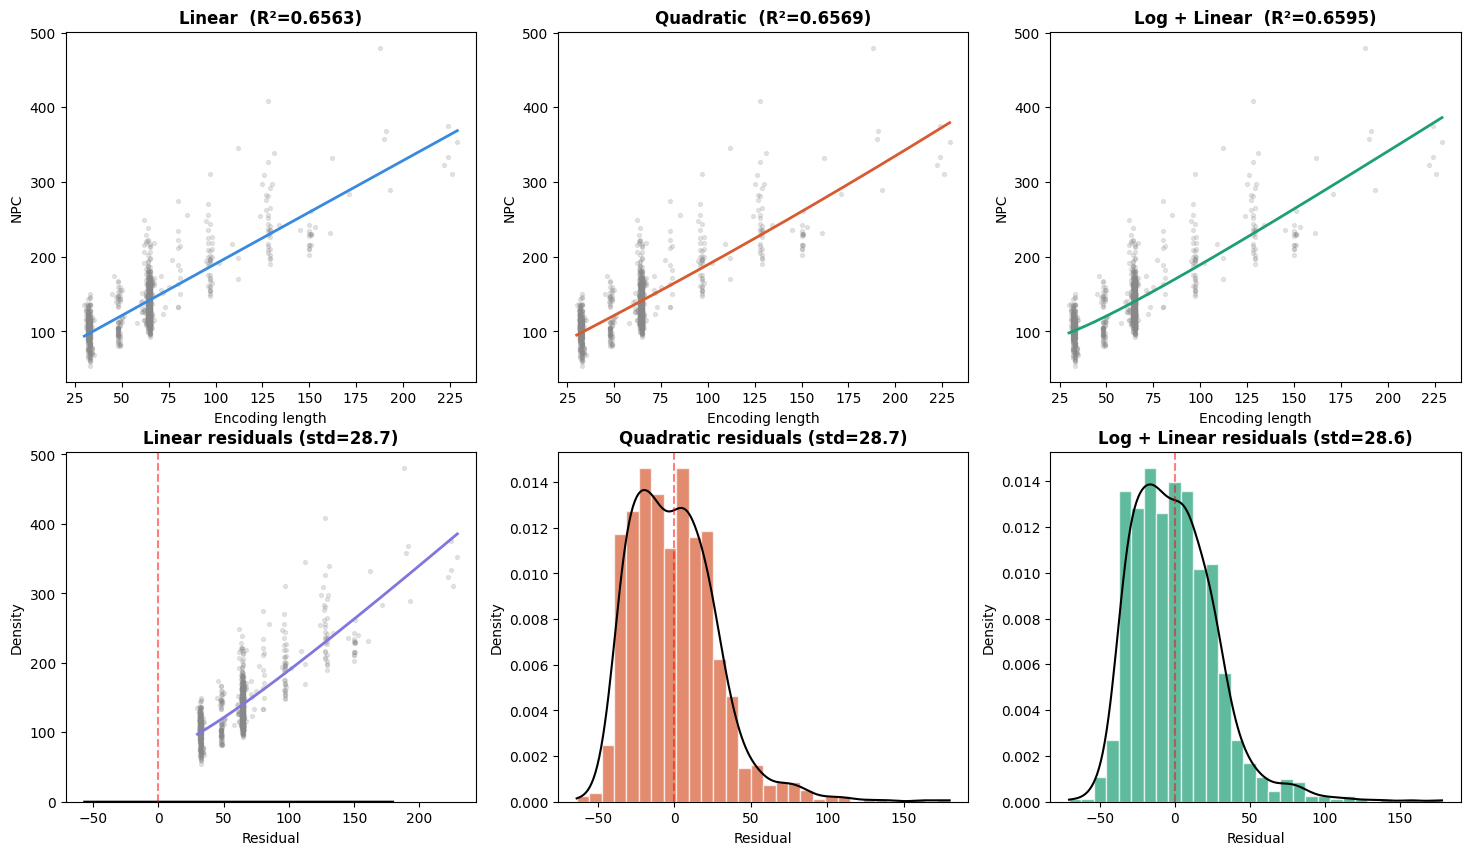

In [ ]:
# =============================================================================
# NPC Length-Adjustment: Model Comparison
# =============================================================================
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

df = pd.read_csv('irish_npc_results.csv')
L = df['encoding_length'].values
N = df['NPC_total'].values

# --- 1. Fit all models ---
models = {}

# No adjustment (raw NPC)
models['No adjustment'] = {
    'pred': np.full_like(N, N.mean(), dtype=float),
    'label': f'NPC = {N.mean():.1f} (constant)',
}

# Linear
c1 = np.polyfit(L, N, 1)
models['Linear'] = {
    'pred': np.poly1d(c1)(L),
    'label': f'NPC = {c1[0]:.2f}·L + {c1[1]:.1f}',
    'coeffs': c1,
}

# Quadratic
c2 = np.polyfit(L, N, 2)
models['Quadratic'] = {
    'pred': np.poly1d(c2)(L),
    'label': f'NPC = {c2[0]:.4f}·L² + {c2[1]:.2f}·L + {c2[2]:.1f}',
    'coeffs': c2,
}

# Log + Linear
X_log = np.column_stack([np.log(L), L, np.ones_like(L)])
c_log, *_ = np.linalg.lstsq(X_log, N, rcond=None)
models['Log + Linear'] = {
    'pred': X_log @ c_log,
    'label': f'NPC = {c_log[0]:.1f}·log(L) + {c_log[1]:.2f}·L + {c_log[2]:.1f}',
    'coeffs': c_log,
}

# Sqrt + Linear
X_sqrt = np.column_stack([np.sqrt(L), L, np.ones_like(L)])
c_sqrt, *_ = np.linalg.lstsq(X_sqrt, N, rcond=None)
models['Sqrt + Linear'] = {
    'pred': X_sqrt @ c_sqrt,
    'label': f'NPC = {c_sqrt[0]:.1f}·√L + {c_sqrt[1]:.2f}·L + {c_sqrt[2]:.1f}',
    'coeffs': c_sqrt,
}

# --- 2. Compute residuals and stats ---
print("=" * 80)
print("MODEL COMPARISON: NPC Length-Adjustment")
print("=" * 80)
print(f"{'Model':<20} {'R²':>8} {'Resid std':>10} {'Resid mean':>11}")
print("-" * 55)

for name, m in models.items():
    resid = N - m['pred']
    r2 = 1 - np.var(resid) / np.var(N)
    m['resid'] = resid
    m['r2'] = r2
    m['resid_std'] = np.std(resid)
    print(f"{name:<20} {r2:>8.4f} {np.std(resid):>10.2f} {np.mean(resid):>11.4f}")

# --- 3. NPC per note analysis ---
print(f"\n{'='*80}")
print("NPC PER NOTE BY LENGTH BIN (evidence of sub-linear growth)")
print(f"{'='*80}")
bins = [0, 40, 60, 80, 100, 140, 250]
df['bin'] = pd.cut(df['encoding_length'], bins=bins)
summary = df.groupby('bin').apply(lambda g: pd.Series({
    'n': len(g),
    'mean_len': g['encoding_length'].mean(),
    'mean_npc': g['NPC_total'].mean(),
    'npc_per_note': g['NPC_total'].mean() / g['encoding_length'].mean()
}))
print(summary.to_string())

# --- 4. Visualisation ---
model_list = [(k, v) for k, v in models.items() if k != 'No adjustment']
n_models = len(model_list)

fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 9))

colors = {'Linear': '#378ADD', 'Quadratic': '#D85A30',
          'Log + Linear': '#1D9E75', 'Sqrt + Linear': '#7F77DD'}

L_grid = np.linspace(L.min(), L.max(), 200)

for ax_idx, (name, m) in enumerate(model_list):
    # Row 1: Fits
    ax = axes[0, ax_idx]
    ax.scatter(L, N, alpha=0.2, s=8, color='#888')
    if name == 'Linear':
        y_grid = np.poly1d(m['coeffs'])(L_grid)
    elif name == 'Quadratic':
        y_grid = np.poly1d(m['coeffs'])(L_grid)
    elif name == 'Log + Linear':
        y_grid = m['coeffs'][0]*np.log(L_grid) + m['coeffs'][1]*L_grid + m['coeffs'][2]
    elif name == 'Sqrt + Linear':
        y_grid = m['coeffs'][0]*np.sqrt(L_grid) + m['coeffs'][1]*L_grid + m['coeffs'][2]
    ax.plot(L_grid, y_grid, color=colors[name], linewidth=2)
    ax.set_title(f"{name}  (R²={m['r2']:.4f})", fontweight='bold')
    ax.set_xlabel('Encoding length'); ax.set_ylabel('NPC')

    # Row 2: Residual distributions
    ax = axes[1, ax_idx]
    resid = m['resid']
    ax.hist(resid, bins=30, density=True, alpha=0.7, color=colors[name], edgecolor='white')
    kde = gaussian_kde(resid)
    x_grid = np.linspace(resid.min(), resid.max(), 200)
    ax.plot(x_grid, kde(x_grid), 'k-', linewidth=1.5)
    ax.set_title(f"Residuals (std={m['resid_std']:.1f})", fontweight='bold')
    ax.set_xlabel('Residual'); ax.set_ylabel('Density')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plots/npc_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# --- 5. Conclusion ---
best = min([(k, v) for k, v in models.items() if k != 'No adjustment'],
           key=lambda x: x[1]['resid_std'])
print(f"\n{'='*80}")
print(f"CONCLUSION")
print(f"{'='*80}")
print(f"Best model by residual std: {best[0]} (std={best[1]['resid_std']:.2f})")
print(f"All models with a linear term give nearly identical R² (~0.656-0.660)")
print(f"The choice of model has minimal impact on downstream KDE scoring.")
print(f"NPC-per-note does decrease with length (from 3.15 to 1.60),")
print(f"confirming sub-linear growth, but the effect is too subtle to")
print(f"meaningfully differentiate regression models at this corpus size.")

In [ ]:
# Save linear model coefficients and residuals into calibration for KDEScorer
linear_coeffs = models['Linear']['coeffs']
linear_residuals = models['Linear']['resid'].tolist()

calibration['npc_poly_coeffs'] = linear_coeffs.tolist()
calibration['npc_residuals'] = linear_residuals

with open('cre_calibration.pkl', 'wb') as f:
    pickle.dump(calibration, f)

print(f"Saved linear model to calibration: NPC = {linear_coeffs[0]:.2f}·L + {linear_coeffs[1]:.1f}")
print(f"Residuals: {len(linear_residuals)} values, std={np.std(linear_residuals):.2f}")

In [ ]:
# bring that in the thesis

import pandas as pd

df = pd.read_csv('irish_npc_results.csv')
print(df['encoding_length'].describe())
print("\nTop 20 most common lengths:")
print(df['encoding_length'].value_counts().head(20))


count    985.000000
mean      61.857868
std       28.718003
min       30.000000
25%       33.000000
50%       64.000000
75%       65.000000
max      229.000000
Name: encoding_length, dtype: float64

Top 20 most common lengths:
encoding_length
65     317
64     156
32     126
33     113
48      44
49      20
97      20
63      19
66      14
128     13
129     12
96      11
34       9
31       9
62       9
150      9
80       8
98       5
151      5
61       5
Name: count, dtype: int64


In [ ]:
# =============================================================================
# Fitness Functions
# =============================================================================

def compute_npc(music_data: dict) -> dict:
    """
    Compute NPC using the same pipeline as the corpus, plus HO/AU costs.
    Returns dict with 'npc' and 'encoding_length'.
    """
    chunks = music_data['chunks']
    ho_p = {k: {"base_segment": v} for k, v in music_data.get('ho_patterns', {}).items()}
    au_p = music_data.get('au_patterns', {})
    grammar_rules = music_data['grammar']
    result = decode(grammar_rules, chunks, ho_patterns=ho_p, au_patterns=au_p, start="p_0")
    chunk_list = result['chunk_data']
    
    if not chunk_list:
        return {'npc': 0.0, 'encoding_length': 0}
    
    encoding, motifs, unique_chunks = encode_chunks_incremental(chunk_list, VAR_FUNCS)
    calc = NPCCalculator()
    npc_result = calc.calculate_npc(encoding, motifs, unique_chunks)
    total = float(npc_result['total'])
    enc_len = len(encoding)
    
    # HO pattern cost
    ho_patterns = music_data.get('ho_patterns', {})
    seen_ho_funcs = set()
    seen_ho_params = {}
    for rule_rhs in grammar_rules.values():
        for sym in rule_rhs:
            for ho_name in ho_patterns:
                if ho_name not in sym:
                    continue
                if sym.startswith(('T(', 'A(', 'D(')) and ho_name in sym:
                    func = sym[0]
                    parts = sym[2:-1].split(',')
                    if len(parts) >= 2:
                        param = parts[-1].strip()
                        key = f"{func}:{param}"
                        if key not in seen_ho_params:
                            seen_ho_params[key] = True
                            total += 1
                elif sym.startswith(('G(', 'I(', 'R(')) and ho_name in sym:
                    func = sym[0]
                    if func not in seen_ho_funcs:
                        seen_ho_funcs.add(func)
                        total += 1
    
    # AU pattern cost
    au_patterns = music_data.get('au_patterns', {})
    for name, info in au_patterns.items():
        total += len(info.get('variables', []))
    
    return {'npc': total, 'encoding_length': enc_len}


def complexity_score(npc_value: float, corpus_mean: float, corpus_std: float) -> float:
    """Gaussian fallback: 1.0 at corpus mean, exp(-0.5 * z^2). Used only when KDE unavailable."""
    if corpus_std <= 0: corpus_std = 1.0
    z = (npc_value - corpus_mean) / corpus_std
    return math.exp(-0.5 * z * z)


class KDEScorer:
    """Score NPC values using KDE on length-adjusted residuals from corpus."""
    def __init__(self, npc_residuals, poly_coeffs):
        from scipy.stats import gaussian_kde
        self.kde = gaussian_kde(npc_residuals)
        self.poly = np.poly1d(poly_coeffs)
        # Find max density for normalisation
        x_grid = np.linspace(min(npc_residuals), max(npc_residuals), 500)
        densities = self.kde(x_grid)
        self.max_density = densities.max()
    
    def score(self, npc_value, encoding_length):
        """Score: is this tune's NPC typical for its length?"""
        predicted = self.poly(encoding_length)
        residual = npc_value - predicted
        density = float(self.kde(residual))
        return min(density / self.max_density, 1.0)


def get_bar_info(time_sig: str) -> dict:
    """Bar length and bin count per time signature."""
    ts_map = {
        '4/4': {'bar_length': 4.0, 'bins': 16}, '3/4': {'bar_length': 3.0, 'bins': 12},
        '2/4': {'bar_length': 2.0, 'bins': 8},  '6/8': {'bar_length': 3.0, 'bins': 12},
        '9/8': {'bar_length': 4.5, 'bins': 18}, '12/8': {'bar_length': 6.0, 'bins': 24},
    }
    info = ts_map.get(time_sig, ts_map['4/4'])
    info['time_sig'] = time_sig
    return info


def compute_rhythm_histogram(melody, time_sig='4/4'):
    """Normalised onset histogram within one bar at 16th-note resolution."""
    bar_info = get_bar_info(time_sig)
    bar_length, bins = bar_info['bar_length'], bar_info['bins']
    if not melody: return tuple([0.0] * bins)
    histogram = [0.0] * bins
    current_time = 0.0
    for pitch, duration in melody:
        bar_pos = current_time % bar_length
        histogram[int((bar_pos / bar_length) * bins) % bins] += 1
        current_time += duration
    total = sum(histogram)
    if total > 0: histogram = [h / total for h in histogram]
    return tuple(histogram)


def cosine_similarity(a, b):
    """Cosine similarity between two vectors."""
    dot = sum(x * y for x, y in zip(a, b))
    na = math.sqrt(sum(x*x for x in a))
    nb = math.sqrt(sum(x*x for x in b))
    return dot / (na * nb) if na > 0 and nb > 0 else 0.0


def rhythm_score(melody_histogram, pattern_tables, time_sig, k=5):
    """KNN rhythm scoring: mean cosine similarity to k nearest corpus patterns."""
    table = pattern_tables.get(time_sig, {})
    if not table: return {'knn_mean': 0.5, 'knn_sims': []}
    # Compute similarity to every corpus pattern
    sims = sorted(
        [cosine_similarity(melody_histogram, pat) for pat in table.keys()],
        reverse=True
    )
    top_k = sims[:min(k, len(sims))]
    return {'knn_mean': sum(top_k) / len(top_k), 'knn_sims': top_k}


class FitnessEvaluator:
    """Weighted sum of complexity (length-adjusted KDE) and rhythm (KNN) scores."""
    def __init__(self, calibration, w_complexity=0.5, w_rhythm=0.5, k=5):
        self.calibration = calibration
        self.w_complexity = w_complexity
        self.w_rhythm = w_rhythm
        self.k = k
        # Build KDE scorer from corpus NPC residuals
        residuals = calibration.get('npc_residuals', [])
        poly_coeffs = calibration.get('npc_poly_coeffs', None)
        if residuals and poly_coeffs:
            self.kde_scorer = KDEScorer(residuals, poly_coeffs)
        else:
            self.kde_scorer = None

    def evaluate(self, melody, music_data=None, time_sig='4/4'):
        try:
            if music_data:
                npc_result = compute_npc(music_data)
                npc = npc_result['npc']
                enc_len = npc_result['encoding_length']
            else:
                npc, enc_len = -1.0, 0
            if npc >= 0 and self.kde_scorer:
                c_score = self.kde_scorer.score(npc, enc_len)
            elif npc >= 0:
                c_score = complexity_score(npc, self.calibration['npc_mean'], self.calibration['npc_std'])
            else:
                c_score = 0.0
        except Exception:
            npc, enc_len, c_score = -1.0, 0, 0.0
        hist = compute_rhythm_histogram(melody, time_sig=time_sig)
        r_result = rhythm_score(hist, self.calibration['pattern_tables'], time_sig, k=self.k)
        r_score = r_result['knn_mean']
        tw = self.w_complexity + self.w_rhythm
        total = (self.w_complexity * c_score + self.w_rhythm * r_score) / tw if tw > 0 else 0.0
        return {'total': total, 'complexity': c_score, 'rhythm': r_score,
                'knn_sims': r_result['knn_sims'], 'npc_value': npc, 'encoding_length': enc_len}

print("Fitness functions defined.")

Fitness functions defined.


In [ ]:
evaluator = FitnessEvaluator(calibration, w_complexity=0.5, w_rhythm=0.5)

def fitness(music_data):
    """Fitness function for PTO. Higher is better."""
    try:
        melody = expand_music_data(music_data)
    except Exception:
        return 0.0
    if not (40 <= len(melody) <= 120):
        return 0.0
    time_sig = music_data.get('time_sig', '4/4')
    return evaluator.evaluate(melody, music_data=music_data, time_sig=time_sig)['total']

# def fitness(music_data):
#     try:
#         melody = expand_music_data(music_data)
#     except Exception:
#         return 0.0
#     time_sig = music_data.get('time_sig', '4/4')
#     result = evaluator.evaluate(melody, music_data=music_data, time_sig=time_sig)
    
#     # Length penalty: 1.0 inside target range, decays outside
#     target_min, target_max = 40, 120
#     n = len(melody)
#     if target_min <= n <= target_max:
#         length_factor = 1.0
#     else:
#         dist = min(abs(n - target_min), abs(n - target_max))
#         length_factor = math.exp(-0.01 * dist * dist)
    
#     return result['total'] * length_factor

# Test
score = fitness(test_data)
print(f"Test tune fitness: {score:.4f}")
result = evaluator.evaluate(test_melody, music_data=test_data, time_sig=test_data['time_sig'])
print(f"  Complexity: {result['complexity']:.4f} (NPC={result['npc_value']:.1f})")
print(f"  Rhythm (KNN-5): {result['rhythm']:.4f}  sims={[round(s,3) for s in result['knn_sims']]}")

Test tune fitness: 0.0000
  Complexity: 0.9778 (NPC=75.0)
  Rhythm (KNN-5): 0.9767  sims=[0.982, 0.977, 0.976, 0.975, 0.973]


/var/folders/cf/ncs9r77x78199vwpl1842v3w0000gn/T/ipykernel_70309/1876304288.py:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  density = float(self.kde(residual))


## 5. Evolution with PTO

PTO's Genetic Algorithm evolves program traces. Crossover and mutation operate on the 
flat trace of `rnd` decisions; replay through the generator produces new music structures.

In [ ]:
# Run PTO GA 20 times, save best evolved tune from each run
os.makedirs('evolved_tunes', exist_ok=True)

scale = [0, 2, 3, 5, 7, 9, 11]
evolved_results = []

for i in range(20):
    print(f"\n{'='*50}")
    print(f"Evolution run {i+1}/20")
    print(f"{'='*50}")
    
    try:
        (pheno, geno), fx, hist = run(
            generate, fitness, better=max,
            Solver='genetic_algorithm',
            solver_args={'n_generation': 100, 'return_history': True}
        )
        
        melody = expand_music_data(pheno)
        ts = pheno.get('time_sig', '4/4')
        result = evaluator.evaluate(melody, music_data=pheno, time_sig=ts)
        
        # Save MIDI
        midi_melody = []
        for p, d in melody:
            midi_pitch = 60 + (p // 7) * 12 + scale[p % 7]
            midi_melody.append((midi_pitch, int(round(d * 480))))
        filename = f'evolved_tunes/evolved_{i:02d}.mid'
        decoder.save_melody_to_midi(midi_melody, filename, ticks_per_beat=480, tempo_bpm=120)
        
        evolved_results.append({
            'id': i, 'notes': len(melody), 'ts': ts,
            'total': result['total'], 'complexity': result['complexity'],
            'rhythm': result['rhythm'], 'npc': result['npc_value'],
            'enc_len': result['encoding_length'], 'history': hist
        })
        
        print(f"  -> {len(melody)} notes, {ts}, fitness={result['total']:.3f} "
              f"(C={result['complexity']:.3f}, R={result['rhythm']:.3f}, NPC={result['npc_value']:.0f})")
    
    except Exception as e:
        print(f"  -> Failed: {e}")

# Summary
print(f"\n{'='*50}")
print(f"SUMMARY: {len(evolved_results)}/20 successful runs")
print(f"{'='*50}")
if evolved_results:
    totals = [r['total'] for r in evolved_results]
    comps = [r['complexity'] for r in evolved_results]
    rhythms = [r['rhythm'] for r in evolved_results]
    npcs = [r['npc'] for r in evolved_results]
    print(f"  Fitness:    mean={np.mean(totals):.3f}, std={np.std(totals):.3f}, range=[{min(totals):.3f}, {max(totals):.3f}]")
    print(f"  Complexity: mean={np.mean(comps):.3f}, std={np.std(comps):.3f}")
    print(f"  Rhythm:     mean={np.mean(rhythms):.3f}, std={np.std(rhythms):.3f}")
    print(f"  NPC:        mean={np.mean(npcs):.0f}, std={np.std(npcs):.0f}")
    print(f"\nSaved {len(evolved_results)} tunes to evolved_tunes/")


Evolution run 1/20
Saved MIDI file: evolved_tunes/evolved_00.mid
  -> 82 notes, 2/4, fitness=0.998 (C=1.000, R=0.995, NPC=65)

Evolution run 2/20
  -> Failed: empty range for randrange() (0, 0, 0)

Evolution run 3/20
Saved MIDI file: evolved_tunes/evolved_02.mid
  -> 102 notes, 2/4, fitness=0.996 (C=1.000, R=0.993, NPC=63)

Evolution run 4/20
Saved MIDI file: evolved_tunes/evolved_03.mid
  -> 102 notes, 2/4, fitness=0.997 (C=1.000, R=0.994, NPC=76)

Evolution run 5/20
Saved MIDI file: evolved_tunes/evolved_04.mid
  -> 110 notes, 4/4, fitness=1.000 (C=1.000, R=0.999, NPC=65)

Evolution run 6/20
Saved MIDI file: evolved_tunes/evolved_05.mid
  -> 68 notes, 2/4, fitness=0.997 (C=1.000, R=0.994, NPC=60)

Evolution run 7/20
Saved MIDI file: evolved_tunes/evolved_06.mid
  -> 104 notes, 2/4, fitness=0.998 (C=1.000, R=0.996, NPC=76)

Evolution run 8/20
Saved MIDI file: evolved_tunes/evolved_07.mid
  -> 110 notes, 6/8, fitness=1.000 (C=1.000, R=0.999, NPC=73)

Evolution run 9/20
Saved MIDI file

In [ ]:
(best_pheno_ga, best_geno_ga), best_fx_ga, history = run(
    generate, fitness, better=max,
    Solver='genetic_algorithm',
    solver_args={'n_generation': 100, 'population_size': 50, 'return_history': True}
)

print(f"\nBest fitness: {best_fx_ga:.4f}")
best_melody_ga = expand_music_data(best_pheno_ga)
print(f"Best melody: {len(best_melody_ga)} notes, time_sig={best_pheno_ga['time_sig']}")


Best fitness: 0.9996
Best melody: 112 notes, time_sig=4/4


In [ ]:
result = evaluator.evaluate(best_melody_ga, music_data=best_pheno_ga, time_sig=best_pheno_ga['time_sig'])
print(f"Fitness breakdown:")
print(f"  Total:      {result['total']:.4f}")
print(f"  Complexity: {result['complexity']:.4f} (NPC={result['npc_value']:.1f}, enc_len={result['encoding_length']}, corpus mean={calibration['npc_mean']:.1f})")
print(f"  Rhythm (KNN-5): {result['rhythm']:.4f}")
print(f"    Top-5 sims: {[round(s,3) for s in result['knn_sims']]}")
print(f"\nStructure:")
print(f"  Chunks: {len(best_pheno_ga['chunks'])}, HO: {len(best_pheno_ga['ho_patterns'])}")
for rule, rhs in best_pheno_ga['grammar'].items():
    print(f"  {rule} -> {' '.join(str(s) for s in rhs)}")

Fitness breakdown:
  Total:      0.9996
  Complexity: 1.0000 (NPC=73.0, enc_len=28, corpus mean=137.8)
  Rhythm (KNN-5): 0.9991
    Top-5 sims: [0.999, 0.999, 0.999, 0.999, 0.999]

Structure:
  Chunks: 5, HO: 1
  p_0 -> p_1 p_2 p_1
  p_1 -> p_3 T(c_0,3) c_2 T(c_3,3) c_0
  p_2 -> T(c_2,5) ho_0 T(ho_0,3) c_1
  p_3 -> T(c_1,5) c_2 H(c_0,0,0.5) H(c_2,0,0.5) c_1


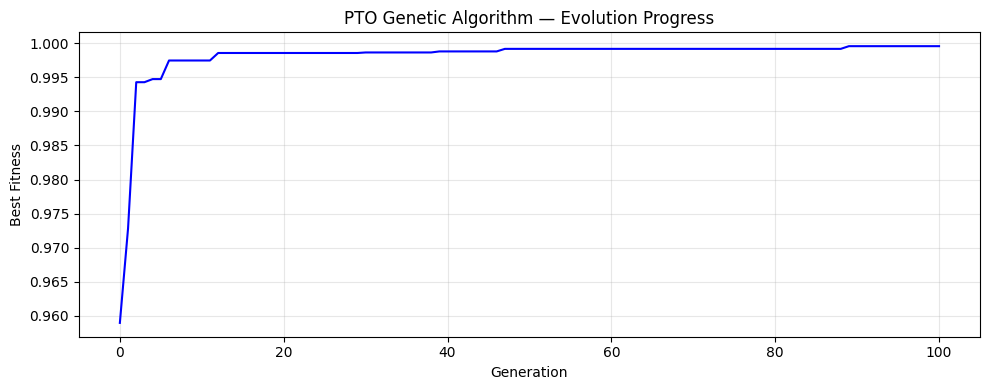

In [ ]:
if history:
    plt.figure(figsize=(10, 4))
    plt.plot(history, 'b-', linewidth=1.5)
    plt.xlabel('Generation'); plt.ylabel('Best Fitness')
    plt.title('PTO Genetic Algorithm \u2014 Evolution Progress')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/evolution_progress.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Analysis & Export

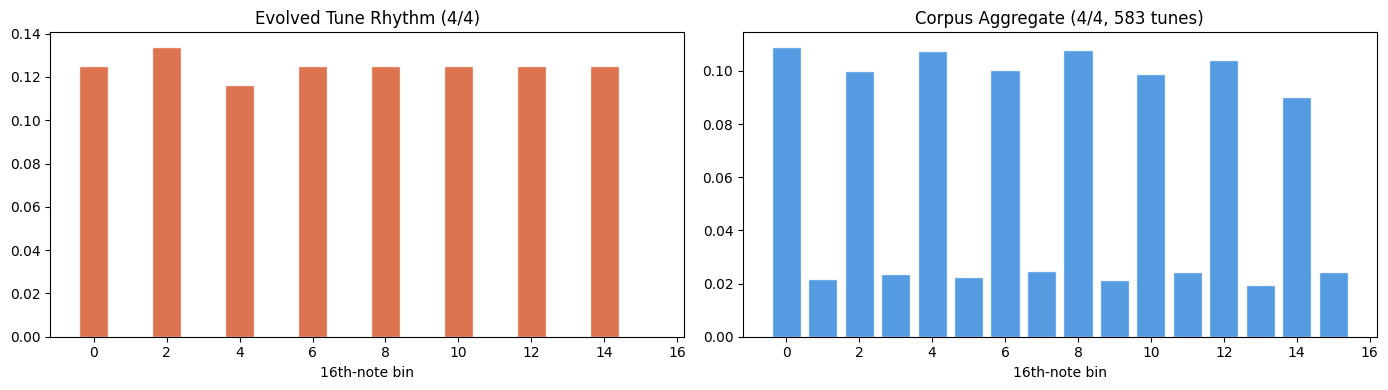

Cosine similarity to corpus aggregate: 0.9730


In [ ]:
ts = best_pheno_ga['time_sig']
hist = compute_rhythm_histogram(best_melody_ga, time_sig=ts)
table = calibration['pattern_tables'].get(ts, {})
if table:
    n_bins = len(next(iter(table)))
    agg = [0.0] * n_bins
    total = sum(table.values())
    for pat, count in table.items():
        for i, v in enumerate(pat): agg[i] += v * count
    s = sum(agg)
    if s > 0: agg = [v / s for v in agg]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(range(len(hist)), hist, color='#D85A30', alpha=0.85, edgecolor='white')
    axes[0].set_title(f"Evolved Tune Rhythm ({ts})"); axes[0].set_xlabel("16th-note bin")
    axes[1].bar(range(len(agg)), agg, color='#378ADD', alpha=0.85, edgecolor='white')
    axes[1].set_title(f"Corpus Aggregate ({ts}, {total} tunes)"); axes[1].set_xlabel("16th-note bin")
    plt.tight_layout()
    plt.savefig('plots/rhythm_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Cosine similarity to corpus aggregate: {cosine_similarity(tuple(hist), tuple(agg)):.4f}")
else:
    print(f"No corpus data for {ts}")

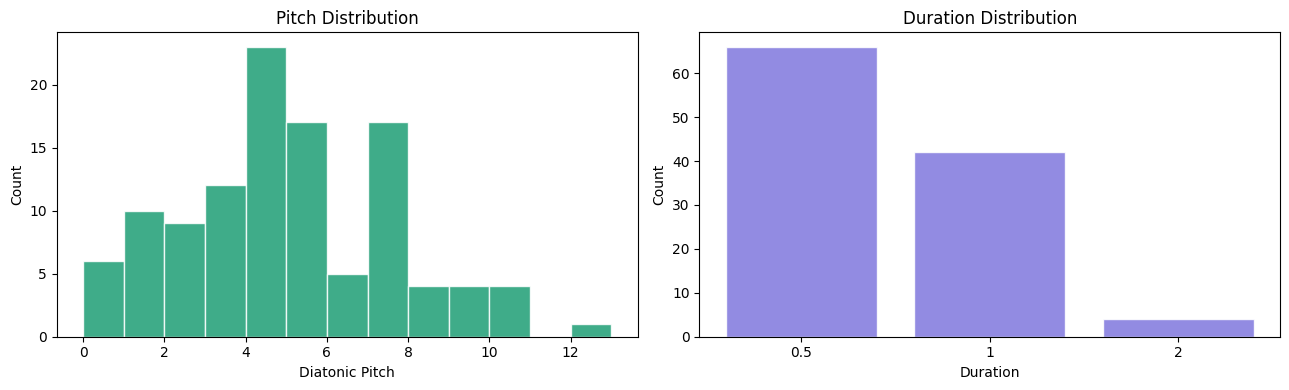

Pitch range: 0 to 12 (12 degrees)
Total duration: 83.0 beats, Unique durations: 3


In [ ]:
pitches = [p for p, d in best_melody_ga]
durations = [d for p, d in best_melody_ga]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(pitches, bins=range(min(pitches), max(pitches)+2), color='#1D9E75', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Diatonic Pitch'); axes[0].set_ylabel('Count'); axes[0].set_title('Pitch Distribution')
dur_counts = Counter(durations)
durs_sorted = sorted(dur_counts.keys())
axes[1].bar([str(d) for d in durs_sorted], [dur_counts[d] for d in durs_sorted], color='#7F77DD', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Duration'); axes[1].set_ylabel('Count'); axes[1].set_title('Duration Distribution')
plt.tight_layout()
plt.savefig('plots/pitch_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Pitch range: {min(pitches)} to {max(pitches)} ({max(pitches)-min(pitches)} degrees)")
print(f"Total duration: {sum(durations):.1f} beats, Unique durations: {len(dur_counts)}")

In [ ]:
def save_to_midi(melody, filename, base_note=60):
    scale = [0, 2, 3, 5, 7, 9, 11]
    midi_melody = []
    for p, d in melody:
        midi_pitch = base_note + (p // 7) * 12 + scale[p % 7]
        midi_melody.append((midi_pitch, int(round(d * 480))))
    decoder.save_melody_to_midi(midi_melody, filename, ticks_per_beat=480, tempo_bpm=120)

save_to_midi(best_melody_ga, 'evolved_irish.mid')
print(f"Saved evolved_irish.mid ({len(best_melody_ga)} notes)")

Saved MIDI file: evolved_irish.mid
Saved evolved_irish.mid (112 notes)
